In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import isautilities as isau
import xarray as xr
import itertools
import scipy as sp
import warnings

import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results' / 'Figures' / 'ISAHpcPfc' / 'XCorr'
froot_poster = pathlib.Path().cwd().parent.parent / 'Results' / 'PosterFigures'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def _laggedSpikeCrossCorr(session,regs=None,cond=['isa','nisa'],bin=0.1,step=3,lags=10,shift=5,pairs=None):
    # compute lagged cross-region pairwise unit correlation (shuffle, region, lag) XArray
    # interpretation: in 'reg1-reg2', reg1 target (controlled by 'target'), reg2 source (all are always computed)
    # time resolution will be 'bin' / 'step'
    # 'shuffle' coordinate is False iff corresponding data values are real

    lags = np.array(lags,ndmin=1)
    if len(lags) == 1:
        lags = np.abs(lags[0])
        lags = np.arange(-lags,lags+1)

    R = fma.regions.regions(session,states=['sws','rem'],events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.array(regs)
    conditions = {'nrem': R.eventIntervals('sws'), 'rem': R.eventIntervals('rem'), 'wake': R.eventIntervals('other'),
                  'isa': R.eventIntervals('slownr'), 'nisa': R.eventIntervals([['sws','/slownr']])}

    # make region pairs
    if pairs is None:
        reg_pair_idx = [list(p) for p in itertools.combinations(range(len(regs)),2)] # make pairs preserving order
    else:
        reg_pair_idx = pairs
    reg_pairs = [f'{regs[rp[0]]}-{regs[rp[1]]}' for rp in reg_pair_idx]
    is_reg = np.isin(regs,R.ids) # is_reg[i] is True if regs[i] is in R.ids

    # 1. unit firing rates per region
    fr = {}
    for j, r in enumerate(regs[is_reg]):
        _fr = R.unitFiringRate(regs=r,window=bin,step=step)
        time = _fr[:,0]
        fr[r] = _fr[:,1:] # (time, unit)
    for cd in cond:
        _, conditions[cd] = fma.general.restrict(time,conditions[cd],s_ind=True)

    rng = np.random.default_rng()
    n_pairs = len(reg_pairs)
    spearman = np.full((len(cond),2,n_pairs,len(lags)),np.nan)
    # conditions
    for c, cd in enumerate(cond):
        valid = conditions[cd]

        # region pairs, reg0: fixed in time, reg1: lagged by 'lag'
        for i, rp in enumerate(reg_pair_idx):
            if is_reg[rp[0]] and is_reg[rp[1]]:
                ref_fr = fr[regs[rp[0]]][valid] # fixed in time

                # 0: observed, 1: surrogate (circular shift of units)
                for k in [0,1]:
                    n_keep_units = fr[regs[rp[1]]].shape[1] # used to recover the cross-correlation block in spearmanr output
                    lagged_fr = fma.general.circularShift(fr[regs[rp[1]]][valid], rng.integers(-shift,shift+1,size=n_keep_units)) if k else fr[regs[rp[1]]][valid]

                    # lags, subsampling by 'step' to avoid overlapping bins ('step' is used just to have finer lags)
                    for l, lag in enumerate(lags):
                        with np.errstate(invalid='ignore'): # suppress 0 / 0 warning
                            with warnings.catch_warnings():
                                warnings.filterwarnings('ignore', category=sp.stats.ConstantInputWarning)
                                if lag > 0:
                                    spr = sp.stats.spearmanr(lagged_fr[:-lag:step], ref_fr[lag::step])[0]
                                elif lag < 0:
                                    spr = sp.stats.spearmanr(lagged_fr[-lag::step], ref_fr[:lag:step])[0]
                                else:
                                    spr = sp.stats.spearmanr(lagged_fr[::step], ref_fr[::step])[0]
                        spearman[c,k,i,l] = np.nanmean(np.abs(spr[:n_keep_units,n_keep_units:]))
    spearman = xr.DataArray(spearman,dims=('cond','shuffle','reg','lag'),coords={'cond': cond, 'shuffle': [False,True], 'reg': reg_pairs, 'lag': lags * (time[1]-time[0]), 'rat': int(R.rat)})
    return spearman

In [3]:
# test one session
session = fma.data.readBatchFile(batch_file)[0][15]
print(f'session: {session}')
xdata = _laggedSpikeCrossCorr(session,step=10,lags=15,shift=10)
#xdata = _laggedSpikeCrossCorr(session,step=10,lags=[-700,-550,-300],shift=10)

session: /mnt/hubel-data-139/karadoc/Rat004_20240227/Rat004_20240227.xml


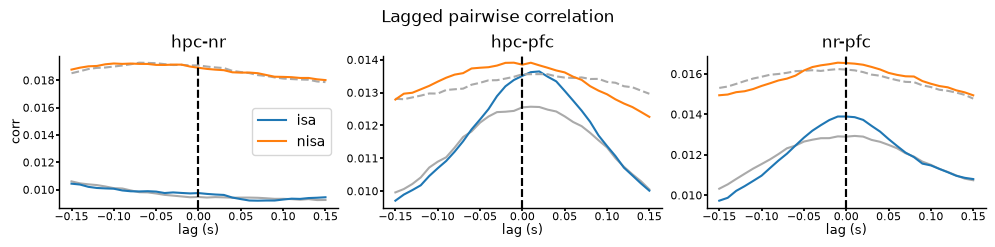

In [4]:
# interpretation: reg0 pop vector correlated with reg1's delayed
fig, ax = fma.plotting.makeFigure(f'Lagged pairwise correlation',n=(1,3),size=(25,6))
ls = ['-','--']
for i, r in enumerate(xdata.reg.values):
    for j, c in enumerate(xdata.cond.values):
        reg_data = xdata.sel(cond=c,reg=r)
        fma.plotting.semPlot(xdata.lag,reg_data.sel(shuffle=True),zscore=False,color=isau.paperColors('shuffle'),ax=ax[i],lprop={'ls': ls[j]})
        ax[i].plot(xdata.lag,reg_data.sel(shuffle=False),label=c)
        ax[i].set_xlabel(f'lag (s)'), ax[i].set_title(r)
        ax[i].axvline(0,ls='--',color='k')
ax[0].set_ylabel('corr'); ax[0].legend();

batch

In [3]:
regs = ['hpc','nr','pfc']
cond = ['isa','nisa','nrem','rem','wake']
corr = fma.data.runBatch(batch_file,_laggedSpikeCrossCorr,kwargs={'regs': regs, 'cond': cond, 'step': 10, 'lags': 15, 'shift': 15},parallel=True)
corr_cat = xr.concat([d for d in corr if d is not None],dim='rat',join='outer')
corr_avg = corr_cat.groupby('rat').mean(dim='rat',skipna=True)


Starting Batch, 2026-09-11 14:08:35.007087 

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
/mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
/mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
/mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230819/Rat002_20230819.xml (38)
'float' object is not subscriptable
Traceback:
Error in session /mnt/hubel-data-129/blinky/Rat002_20230822/Rat002_20230822.xml (41)
/mnt/hubel-data-129/blinky/Rat002_20230822/Rat002_20230822.sws not found.
Traceback:
Error in session /mnt/hubel-data-129/blinky/Rat002_20230823/Rat002_20230823.xml

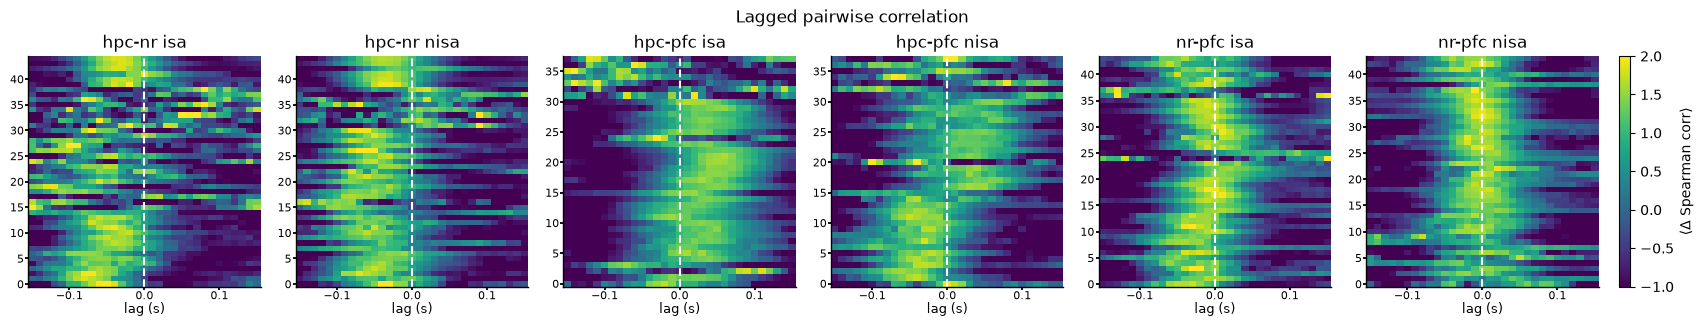

In [7]:
# REMOVE BASELINE BY COMPUTING corr in [-3,-2] per condition, averaging and subtract from curves
# IF GIVES PROBLEMS, BASELINE CAN BE SAME BUT ON ALL DATA, no conditions
fig, ax = fma.plotting.makeFigure(f'Lagged pairwise correlation',n=(1,6),size=(43,8))
cd = ['isa','nisa']
vmin = -1 # 0.00000
vmax = 2 # 0.001
label = [None,None,None,None,None,r'$\langle$Δ Spearman corr$\rangle$']
for i, r in enumerate(corr_cat.reg.values):
    for j, c in enumerate(cd):
        reg_data = corr_cat.sel(reg=r,cond=c)
        reg_data = reg_data.sel(shuffle=False) - reg_data.sel(shuffle=True)
        # plot
        fma.plotting.plotColorMap(reg_data,x=reg_data.lag,vmin=vmin,vmax=vmax,zscore=1,omitnan=1,bar=label[2*i+j],ax=ax[2*i+j])
        ax[2*i+j].set(title=f'{r} {c}',xlabel=f'lag (s)')
        ax[2*i+j].axvline(0,ls='--',color='w')

False

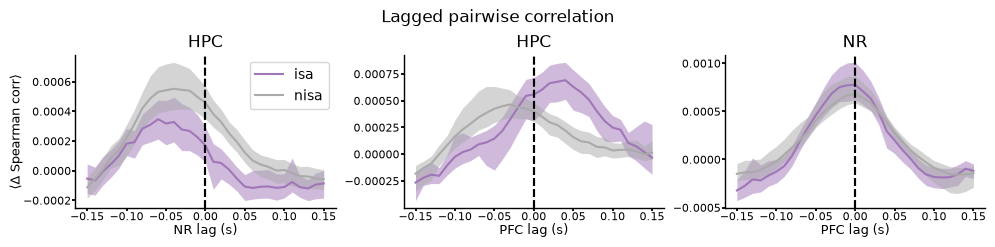

In [4]:
fig, ax = fma.plotting.makeFigure(f'Lagged pairwise correlation',n=(1,3),size=(25,6))
ls = ['-','--']
color = isau.paperColors(['nr','shuffle'])
for i, r in enumerate(corr_cat.reg.values):
    for j, c in enumerate(cond[:2]):
        reg_data = corr_cat.sel(cond=c,reg=r)
        reg_data = reg_data.sel(shuffle=False) - reg_data.sel(shuffle=True)
        fma.plotting.semPlot(reg_data.lag,reg_data,label=c,color=color[j],ax=ax[i])
        #fma.plotting.semPlot(reg_data.lag,reg_data.sel(shuffle=True),color=isau.paperColors('shuffle'),ax=ax[i],lprop={'ls': ls[j]})
        #fma.plotting.semPlot(reg_data.lag,reg_data.sel(shuffle=False),label=c,ax=ax[i])
        ax[i].set(title=r.split('-')[0].upper(),xlabel=f'{r.split('-')[1].upper()} lag (s)')
        ax[i].axvline(0,ls='--',color='k')
ax[0].set_ylabel(r'$\langle$Δ Spearman corr$\rangle$'); ax[0].legend()
do_save and fma.plotting.saveFigure(fig,froot / 'ISAnISAXCorr',('png','svg'))

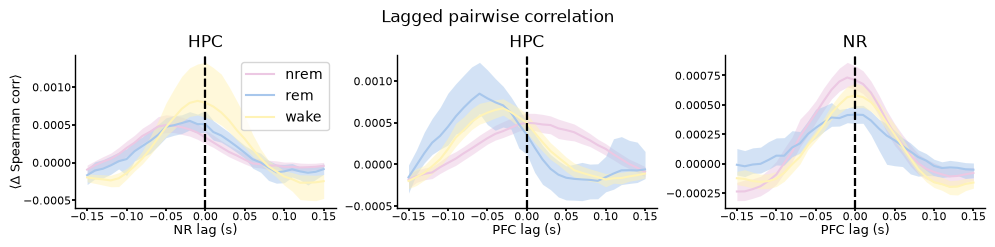

In [14]:
fig, ax = fma.plotting.makeFigure(f'Lagged pairwise correlation',n=(1,3),size=(25,6))
ls = ['-','--','-.']
color = isau.paperColors(['sws','rem','wake'])
for i, r in enumerate(corr_cat.reg.values):
    for j, c in enumerate(cond[2:]):
        reg_data = corr_cat.sel(cond=c,reg=r)
        reg_data = reg_data.sel(shuffle=False) - reg_data.sel(shuffle=True)
        fma.plotting.semPlot(reg_data.lag,reg_data,label=c,color=color[j],ax=ax[i])
        #fma.plotting.semPlot(reg_data.lag,reg_data.sel(shuffle=True),color=isau.paperColors('shuffle'),ax=ax[i],lprop={'ls': ls[j]})
        #fma.plotting.semPlot(reg_data.lag,reg_data.sel(shuffle=False),label=c,ax=ax[i])
        ax[i].set(title=r.split('-')[0].upper(),xlabel=f'{r.split('-')[1].upper()} lag (s)')
        ax[i].axvline(0,ls='--',color='k')
ax[0].set_ylabel(r'$\langle$Δ Spearman corr$\rangle$'); ax[0].legend()
do_save and fma.plotting.saveFigure(fig,froot / 'statesXCorr',('png','svg'))

poster figures

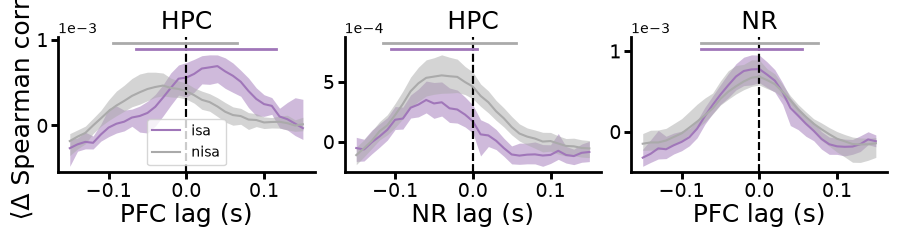

In [39]:
fig, ax = fma.plotting.makeFigure(n=(1,3),size=(9,2.3),format='poster')
ls = ['-','--']
color = isau.paperColors(['nr','shuffle'])
for i, r in enumerate(corr_cat.reg.values[[1,0,2]]):
    for j, c in enumerate(cond[:2]):
        ax[i].axvline(0,ls='--',color='k')
        reg_data = corr_cat.sel(cond=c,reg=r)
        reg_data = reg_data.sel(shuffle=False) - reg_data.sel(shuffle=True)
        fma.plotting.semPlot(reg_data.lag,reg_data,label=c,color=color[j],ax=ax[i])
        ax[i].set(xlabel=f'{r.split('-')[1].upper()} lag (s)')
        ax[i].set_title(r.split('-')[0].upper(),fontsize=18)
        ax[i].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
# stats
for i, r in enumerate(corr_cat.reg.values[[1,0,2]]):
    for j, c in enumerate(cond[:2]):
        reg_data = corr_cat.sel(cond=c,reg=r)
        reg_data = reg_data.sel(shuffle=False) - reg_data.sel(shuffle=True)
        p = sp.stats.wilcoxon(reg_data,axis=0,alternative='greater',nan_policy='omit').pvalue
        _, p = fma.analysis.holmBonferroni(p, return_reject=True)
        fma.plotting.pHorzLine(p, reg_data.lag, color=color[j], lw=2, ax=ax[i])
ax[0].set_ylabel(r'$\langle$Δ Spearman corr$\rangle$'); ax[0].legend()
do_save and fma.plotting.saveFigure(fig,froot_poster / 'ISAnISAXCorr',('png','svg'))

TEST lag direction

In [ ]:
# test one session LAG = -10: reg0[:-10], fixed in time, reg1[10:], lagged in the past (-l seconds)
session = fma.data.readBatchFile(batch_file)[0][15]
print(f'session: {session}')
xdata = _laggedSpikeCrossCorr(session,step=10,lags=[-10,-9],shift=10,pairs=[[0,1]])

session: /mnt/hubel-data-139/karadoc/Rat004_20240227/Rat004_20240227.xml
